# OWL2Bench difficulty vs accuracy analysis

This notebook:
- reads the OWL2Bench result Excel files from `data/output/llm_results`
- computes correctness for the three LLMs
- scores MC questions by overlap fraction
- creates and saves 30 plots:
  - 5 parameters × 3 settings (`nl`, `ab`, `ttl`) × 2 hops (`1hop`, `2hop`)
- saves summary CSV tables

In [13]:
from pathlib import Path
from typing import Optional
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

In [ ]:
def find_project_root(start: Optional[Path] = None) -> Path:
    candidates = []
    if start is not None:
        candidates.append(start.resolve())
    candidates.append(Path.cwd().resolve())

    seen = set()
    for candidate in candidates:
        for place in [candidate, *candidate.parents]:
            if place in seen:
                continue
            seen.add(place)
            if (place / "pom.xml").exists() and (place / "data").exists():
                return place

    raise FileNotFoundError(
        "Could not locate the project root. Open this notebook from inside the CORE-LLM-Bench repo."
    )

PROJECT_ROOT = find_project_root()
OUTPUT_ROOT = PROJECT_ROOT / "data" / "output"
LLM_RESULTS_ROOT = OUTPUT_ROOT / "llm_results"

ONTOLOGIES = ["OWL2Bench"]
HOPS = ["1hop", "2hop"]

SETTING_FILES = {
    "nl": "nl_results_FINAL.xlsx",
    "ab": "abstract_results_FINAL.xlsx",
    "ttl": "ttl_results_FINAL.xlsx",
}

ANALYSIS_DIR = OUTPUT_ROOT / "difficulty_accuracy_analysis_owl2bench"
PLOTS_DIR = ANALYSIS_DIR / "plots"
TABLES_DIR = ANALYSIS_DIR / "tables"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

ABOX_BIN_WIDTH = 2
TAG_THRESHOLD_PLUS = 8

MODEL_FINAL_ANSWER_COLS = {
    "deepseek-chat": "deepseek-chat_final_answer",
    "gpt-5-mini": "gpt-5-mini_final_answer",
    "llama-4-maverick": "llama-4-maverick_final_answer",
}

MODEL_SCORE_COLS = {model: f"{model}_score" for model in MODEL_FINAL_ANSWER_COLS}

PARAMETERS = {
    "abox_size": {
        "source_col": "Size of ontology ABox",
        "title_label": "ABox size",
    },
    "answer_type": {
        "source_col": "Answer Type",
        "title_label": "Answer Type",
    },
    "task_type": {
        "source_col": "Task Type",
        "title_label": "Task Type",
    },
    "min_tag_length": {
        "source_col": "Min Tag Length",
        "title_label": "Min Tag Length",
    },
    "max_tag_length": {
        "source_col": "Max Tag Length",
        "title_label": "Max Tag Length",
    },
}

print("PROJECT_ROOT =", PROJECT_ROOT)
print("LLM_RESULTS_ROOT =", LLM_RESULTS_ROOT)
print("PLOTS_DIR =", PLOTS_DIR)
print("TABLES_DIR =", TABLES_DIR)

PROJECT_ROOT = C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2
LLM_RESULTS_ROOT = C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\llm_results
PLOTS_DIR = C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_analysis_owl2bench\plots
TABLES_DIR = C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_analysis_owl2bench\tables


In [15]:
def find_result_file(ontology_name: str, hop: str, setting: str) -> Path:
    folder = LLM_RESULTS_ROOT / f"{ontology_name}_{hop}"
    filename = SETTING_FILES[setting]
    path = folder / filename
    if not path.exists():
        raise FileNotFoundError(f"Could not find file: {path}")
    return path

def load_result_file(path: Path) -> pd.DataFrame:
    if path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    raise ValueError(f"Unsupported file format: {path.suffix}")

In [16]:
def normalize_scalar_answer(value) -> str:
    if pd.isna(value):
        return ""
    text = str(value).strip()
    text = re.sub(r"\s+", " ", text)
    return text.casefold()

def split_mc_answers(value) -> list[str]:
    if pd.isna(value):
        return []
    parts = [p.strip() for p in str(value).split(";")]
    parts = [p for p in parts if p != ""]
    return [normalize_scalar_answer(p) for p in parts]

def score_answer(row: pd.Series, pred_col: str) -> float:
    gold = row.get("Answer", np.nan)
    pred = row.get(pred_col, np.nan)
    answer_type = str(row.get("Answer Type", "")).strip().upper()

    if answer_type == "MC":
        gold_items = split_mc_answers(gold)
        pred_items = split_mc_answers(pred)

        if len(gold_items) == 0:
            return np.nan

        gold_set = set(gold_items)
        pred_set = set(pred_items)
        return len(gold_set.intersection(pred_set)) / len(gold_set)

    gold_norm = normalize_scalar_answer(gold)
    pred_norm = normalize_scalar_answer(pred)
    return float(gold_norm == pred_norm)

def add_model_scores(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for model, pred_col in MODEL_FINAL_ANSWER_COLS.items():
        if pred_col not in out.columns:
            raise KeyError(f"Missing required prediction column: {pred_col}")
        out[MODEL_SCORE_COLS[model]] = out.apply(lambda row: score_answer(row, pred_col), axis=1)
    out["overall_accuracy"] = out[list(MODEL_SCORE_COLS.values())].mean(axis=1)
    return out

In [17]:
def make_abox_bins(series: pd.Series, width: int = 10) -> pd.Categorical:
    s = pd.to_numeric(series, errors="coerce")
    max_value = int(np.nanmax(s)) if s.notna().any() else 0
    upper = int(math.ceil((max_value + 1) / width) * width)
    edges = list(range(0, upper + 1, width))
    if len(edges) < 2:
        edges = [0, width]
    labels = [f"{start}-{start + width - 1}" for start in edges[:-1]]
    return pd.cut(s, bins=edges, labels=labels, include_lowest=True, right=False)

def make_tag_bins(series: pd.Series, threshold_plus: int = 8) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")

    def bin_one(x):
        if pd.isna(x):
            return np.nan
        x = int(x)
        if x >= threshold_plus:
            return f"{threshold_plus}+"
        return str(x)

    ordered = [str(i) for i in range(1, threshold_plus)] + [f"{threshold_plus}+"]
    out = s.apply(bin_one)
    return pd.Categorical(out, categories=ordered, ordered=True)

def make_two_class_bins(series: pd.Series, categories: list[str]) -> pd.Categorical:
    s = series.astype(str).str.strip()
    return pd.Categorical(s, categories=categories, ordered=True)

def add_parameter_bin_column(df: pd.DataFrame, parameter_key: str) -> pd.DataFrame:
    out = df.copy()

    if parameter_key == "abox_size":
        out["parameter_bin"] = make_abox_bins(out["Size of ontology ABox"], width=ABOX_BIN_WIDTH)
    elif parameter_key == "answer_type":
        out["parameter_bin"] = make_two_class_bins(out["Answer Type"], ["BIN", "MC"])
    elif parameter_key == "task_type":
        out["parameter_bin"] = make_two_class_bins(out["Task Type"], ["Property Assertion", "Membership"])
    elif parameter_key == "min_tag_length":
        out["parameter_bin"] = make_tag_bins(out["Min Tag Length"], threshold_plus=TAG_THRESHOLD_PLUS)
    elif parameter_key == "max_tag_length":
        out["parameter_bin"] = make_tag_bins(out["Max Tag Length"], threshold_plus=TAG_THRESHOLD_PLUS)
    else:
        raise ValueError(f"Unknown parameter_key: {parameter_key}")

    return out

In [18]:
def build_accuracy_table(df: pd.DataFrame, parameter_key: str) -> pd.DataFrame:
    tmp = add_parameter_bin_column(df, parameter_key).copy()
    tmp = tmp[tmp["parameter_bin"].notna()].copy()

    grouped = tmp.groupby("parameter_bin", observed=False)

    agg = grouped.agg(
        n_questions=("Task ID", "count"),
        deepseek_chat_accuracy=(MODEL_SCORE_COLS["deepseek-chat"], "mean"),
        gpt_5_mini_accuracy=(MODEL_SCORE_COLS["gpt-5-mini"], "mean"),
        llama_4_maverick_accuracy=(MODEL_SCORE_COLS["llama-4-maverick"], "mean"),
        overall_accuracy=("overall_accuracy", "mean"),
    ).reset_index()

    agg["parameter_bin"] = agg["parameter_bin"].astype(str)
    return agg

In [19]:
def plot_accuracy_histogram(
    agg_df: pd.DataFrame,
    ontology_name: str,
    hop: str,
    setting: str,
    parameter_key: str,
    save_path: Optional[Path] = None,
    show_plot: bool = False,
):
    title_label = PARAMETERS[parameter_key]["title_label"]

    if parameter_key == "abox_size":
        subtitle = f"Accuracy by {title_label} (bin width = {ABOX_BIN_WIDTH})"
        xlabel = f"{title_label}\n(n = query count)"
    elif parameter_key in ["min_tag_length", "max_tag_length"]:
        subtitle = f"Accuracy by {title_label} (bins: 1-{TAG_THRESHOLD_PLUS - 1}, {TAG_THRESHOLD_PLUS}+)"
        xlabel = f"{title_label}\n(n = query count)"
    else:
        subtitle = f"Accuracy by {title_label}"
        xlabel = f"{title_label}\n(n = query count)"

    x_labels = [
        f"{label}\n(n={int(n)})"
        for label, n in zip(agg_df["parameter_bin"], agg_df["n_questions"])
    ]

    x = np.arange(len(agg_df))

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.bar(x, agg_df["overall_accuracy"], alpha=0.35, label="overall accuracy")
    ax.scatter(x, agg_df["deepseek_chat_accuracy"], s=90, label="deepseek-chat", zorder=3)
    ax.scatter(x, agg_df["gpt_5_mini_accuracy"], s=90, label="gpt-5-mini", zorder=3)
    ax.scatter(x, agg_df["llama_4_maverick_accuracy"], s=90, label="llama-4-maverick", zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Accuracy")
    ax.set_xlabel(xlabel)
    ax.set_title(f"{ontology_name} — {hop} — {setting}\n{subtitle}")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="Model / overall")

    plt.tight_layout()

    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")

    if show_plot:
        plt.show()
    else:
        plt.close(fig)

In [20]:
def run_owl2bench_analysis(show_plots: bool = False, save_tables: bool = True):
    all_plot_paths = []
    all_summary_tables = {}

    PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    TABLES_DIR.mkdir(parents=True, exist_ok=True)

    print("Saving plots to:", PLOTS_DIR)

    for ontology_name in ONTOLOGIES:
        for hop in HOPS:
            for setting in SETTING_FILES:
                file_path = find_result_file(ontology_name, hop, setting)
                print(f"\nReading: {file_path}")

                df = load_result_file(file_path)
                df = add_model_scores(df)

                for parameter_key in PARAMETERS:
                    agg_df = build_accuracy_table(df, parameter_key)

                    filename = f"{ontology_name}_{hop}_{setting}_{parameter_key}_accuracy.png"
                    save_path = PLOTS_DIR / filename

                    plot_accuracy_histogram(
                        agg_df=agg_df,
                        ontology_name=ontology_name,
                        hop=hop,
                        setting=setting,
                        parameter_key=parameter_key,
                        save_path=save_path,
                        show_plot=show_plots,
                    )

                    if save_path.exists():
                        all_plot_paths.append(save_path)

                    if save_tables:
                        table_name = f"{ontology_name}_{hop}_{setting}_{parameter_key}"
                        all_summary_tables[table_name] = agg_df.copy()
                        agg_df.to_csv(TABLES_DIR / f"{table_name}.csv", index=False)

    print(f"\nTotal saved plots: {len(all_plot_paths)}")
    return {
        "plots": all_plot_paths,
        "tables": all_summary_tables,
    }

In [21]:
results = run_owl2bench_analysis(show_plots=False, save_tables=True)

Saving plots to: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_analysis_owl2bench\plots

Reading: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\llm_results\OWL2Bench_1hop\nl_results_FINAL.xlsx

Reading: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\llm_results\OWL2Bench_1hop\abstract_results_FINAL.xlsx

Reading: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\llm_results\OWL2Bench_1hop\ttl_results_FINAL.xlsx

Reading: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\llm_results\OWL2Bench_2hop\nl_results_FINAL.xlsx

Reading: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\llm_results\OWL2Bench_2hop\abstract_results_FINAL.xlsx

Reading: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\llm_results\OWL2Bench_2hop\ttl_results_FINAL.xlsx

Total saved plot

In [22]:
print("Saved plot count:", len(results["plots"]))
for p in results["plots"][:10]:
    print(p)

Saved plot count: 30
C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_analysis_owl2bench\plots\OWL2Bench_1hop_nl_abox_size_accuracy.png
C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_analysis_owl2bench\plots\OWL2Bench_1hop_nl_answer_type_accuracy.png
C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_analysis_owl2bench\plots\OWL2Bench_1hop_nl_task_type_accuracy.png
C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_analysis_owl2bench\plots\OWL2Bench_1hop_nl_min_tag_length_accuracy.png
C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_analysis_owl2bench\plots\OWL2Bench_1hop_nl_max_tag_length_accuracy.png
C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_analysis_owl2bench\plots\OWL2Bench_1hop_ab_

In [23]:
print("All saved PNG files:")
for p in sorted(PLOTS_DIR.glob("*.png")):
    print(p.name)

All saved PNG files:
OWL2Bench_1hop_ab_abox_size_accuracy.png
OWL2Bench_1hop_ab_answer_type_accuracy.png
OWL2Bench_1hop_ab_max_tag_length_accuracy.png
OWL2Bench_1hop_ab_min_tag_length_accuracy.png
OWL2Bench_1hop_ab_task_type_accuracy.png
OWL2Bench_1hop_nl_abox_size_accuracy.png
OWL2Bench_1hop_nl_answer_type_accuracy.png
OWL2Bench_1hop_nl_max_tag_length_accuracy.png
OWL2Bench_1hop_nl_min_tag_length_accuracy.png
OWL2Bench_1hop_nl_task_type_accuracy.png
OWL2Bench_1hop_ttl_abox_size_accuracy.png
OWL2Bench_1hop_ttl_answer_type_accuracy.png
OWL2Bench_1hop_ttl_max_tag_length_accuracy.png
OWL2Bench_1hop_ttl_min_tag_length_accuracy.png
OWL2Bench_1hop_ttl_task_type_accuracy.png
OWL2Bench_2hop_ab_abox_size_accuracy.png
OWL2Bench_2hop_ab_answer_type_accuracy.png
OWL2Bench_2hop_ab_max_tag_length_accuracy.png
OWL2Bench_2hop_ab_min_tag_length_accuracy.png
OWL2Bench_2hop_ab_task_type_accuracy.png
OWL2Bench_2hop_nl_abox_size_accuracy.png
OWL2Bench_2hop_nl_answer_type_accuracy.png
OWL2Bench_2hop_nl_max_

## Optional: display a few sample plots inside the notebook

OWL2Bench_1hop_nl_abox_size_accuracy.png


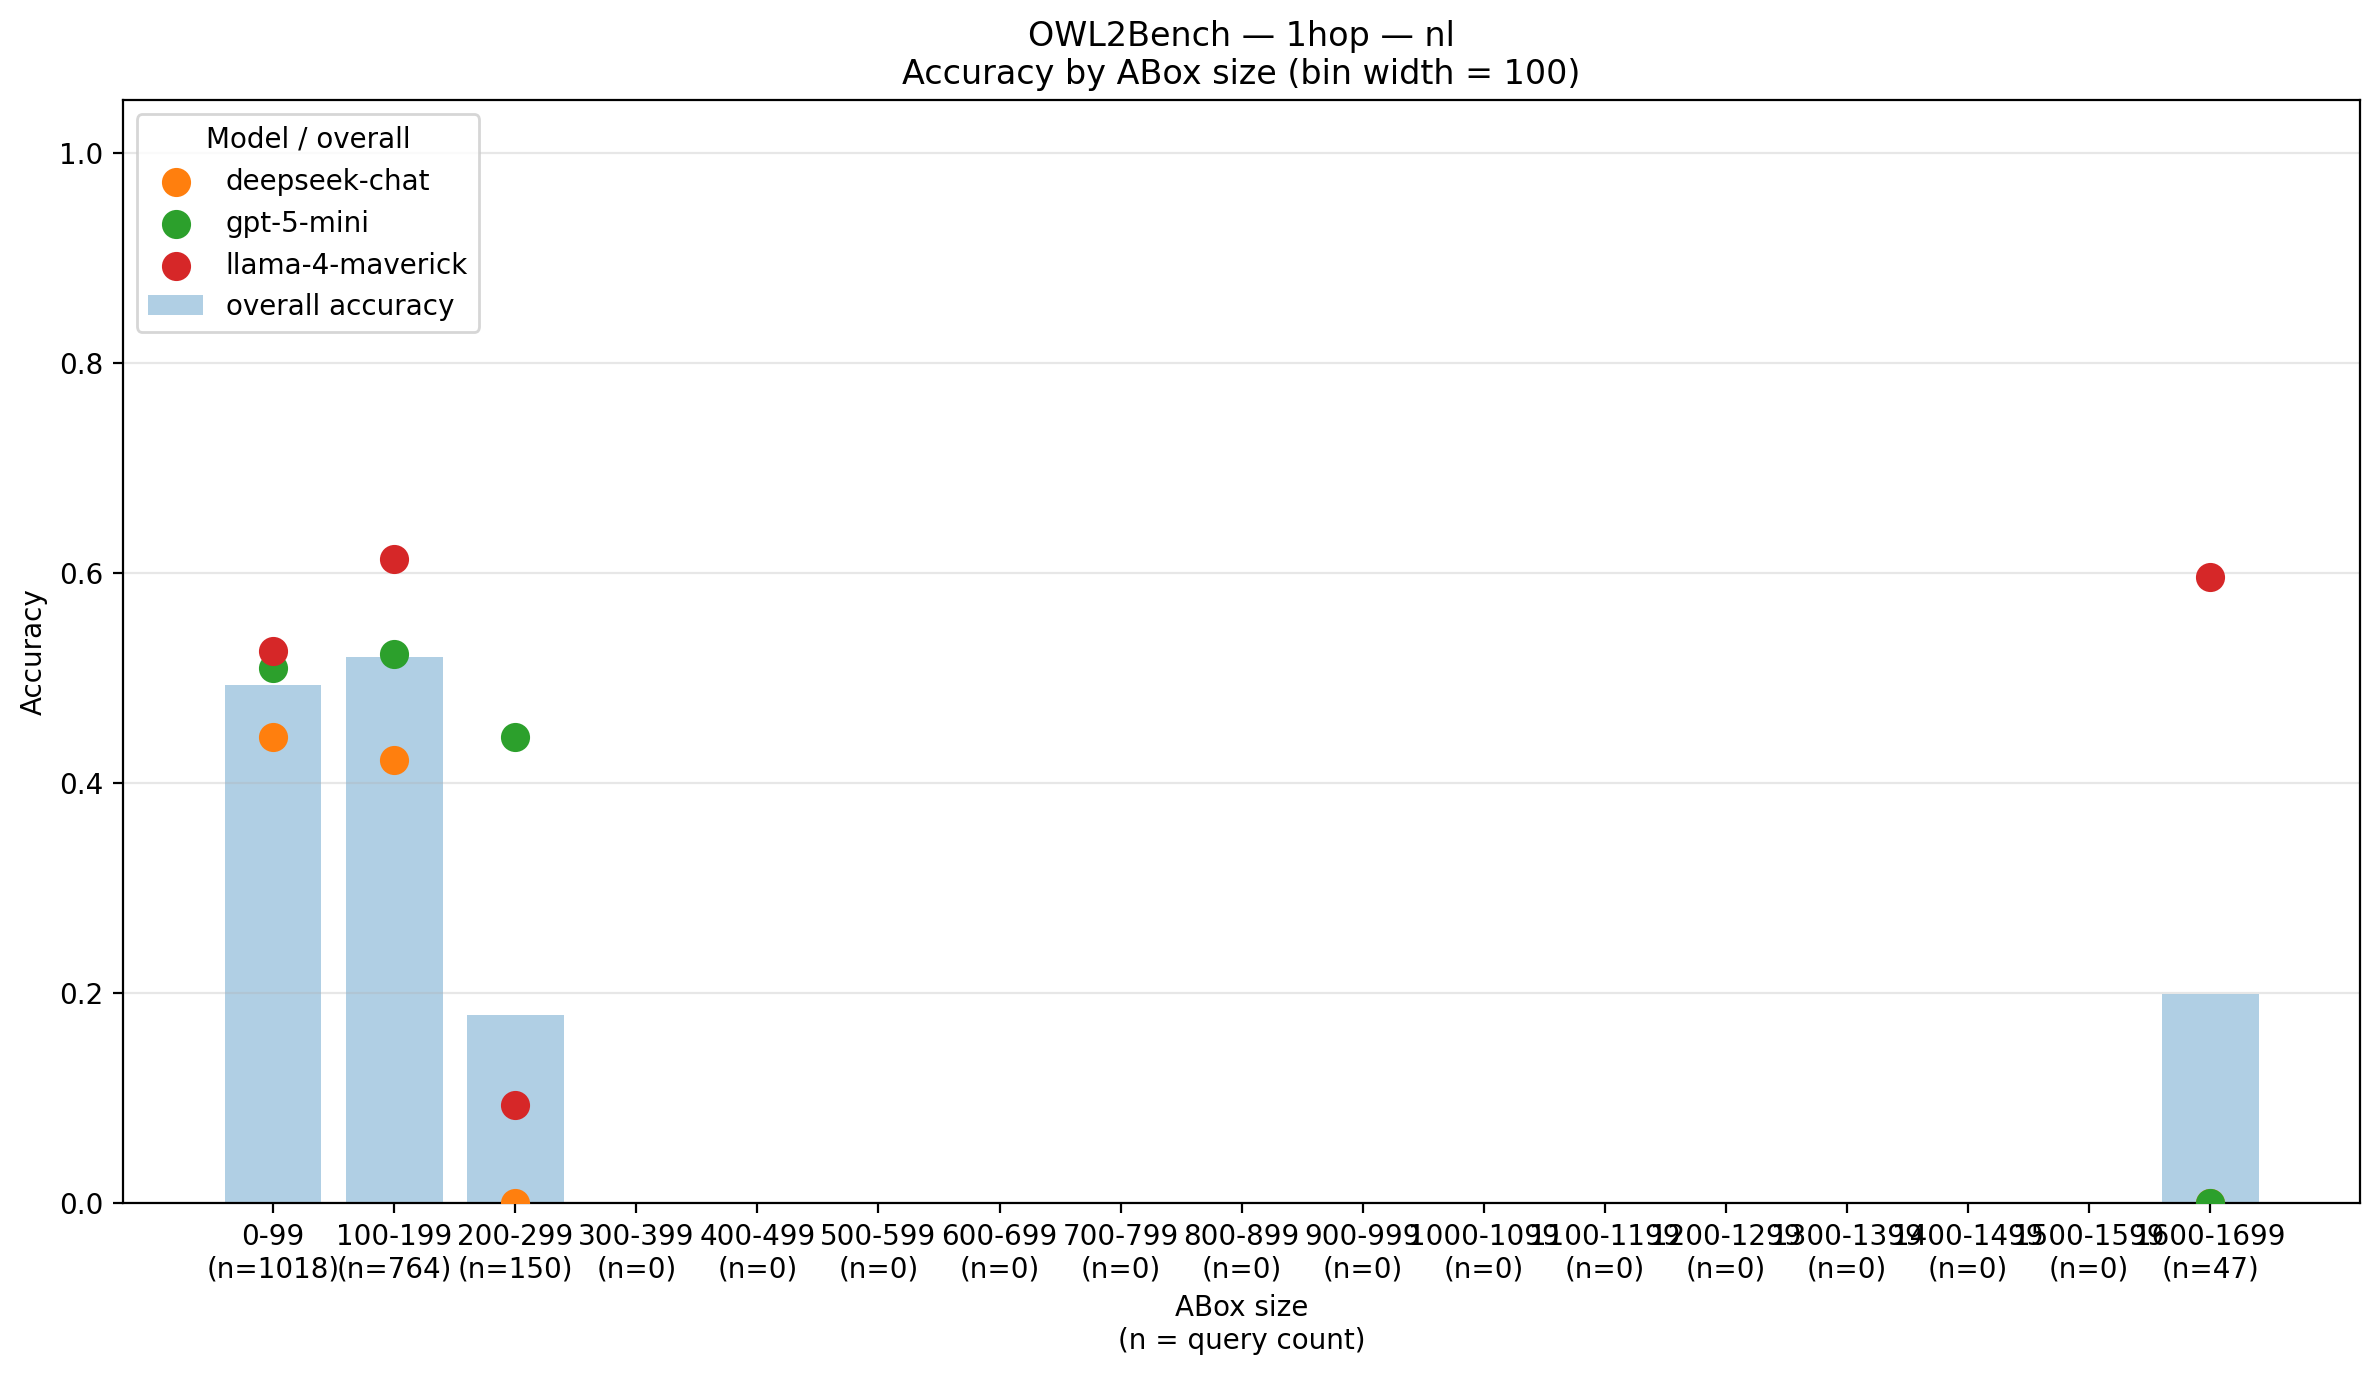

OWL2Bench_1hop_ttl_answer_type_accuracy.png


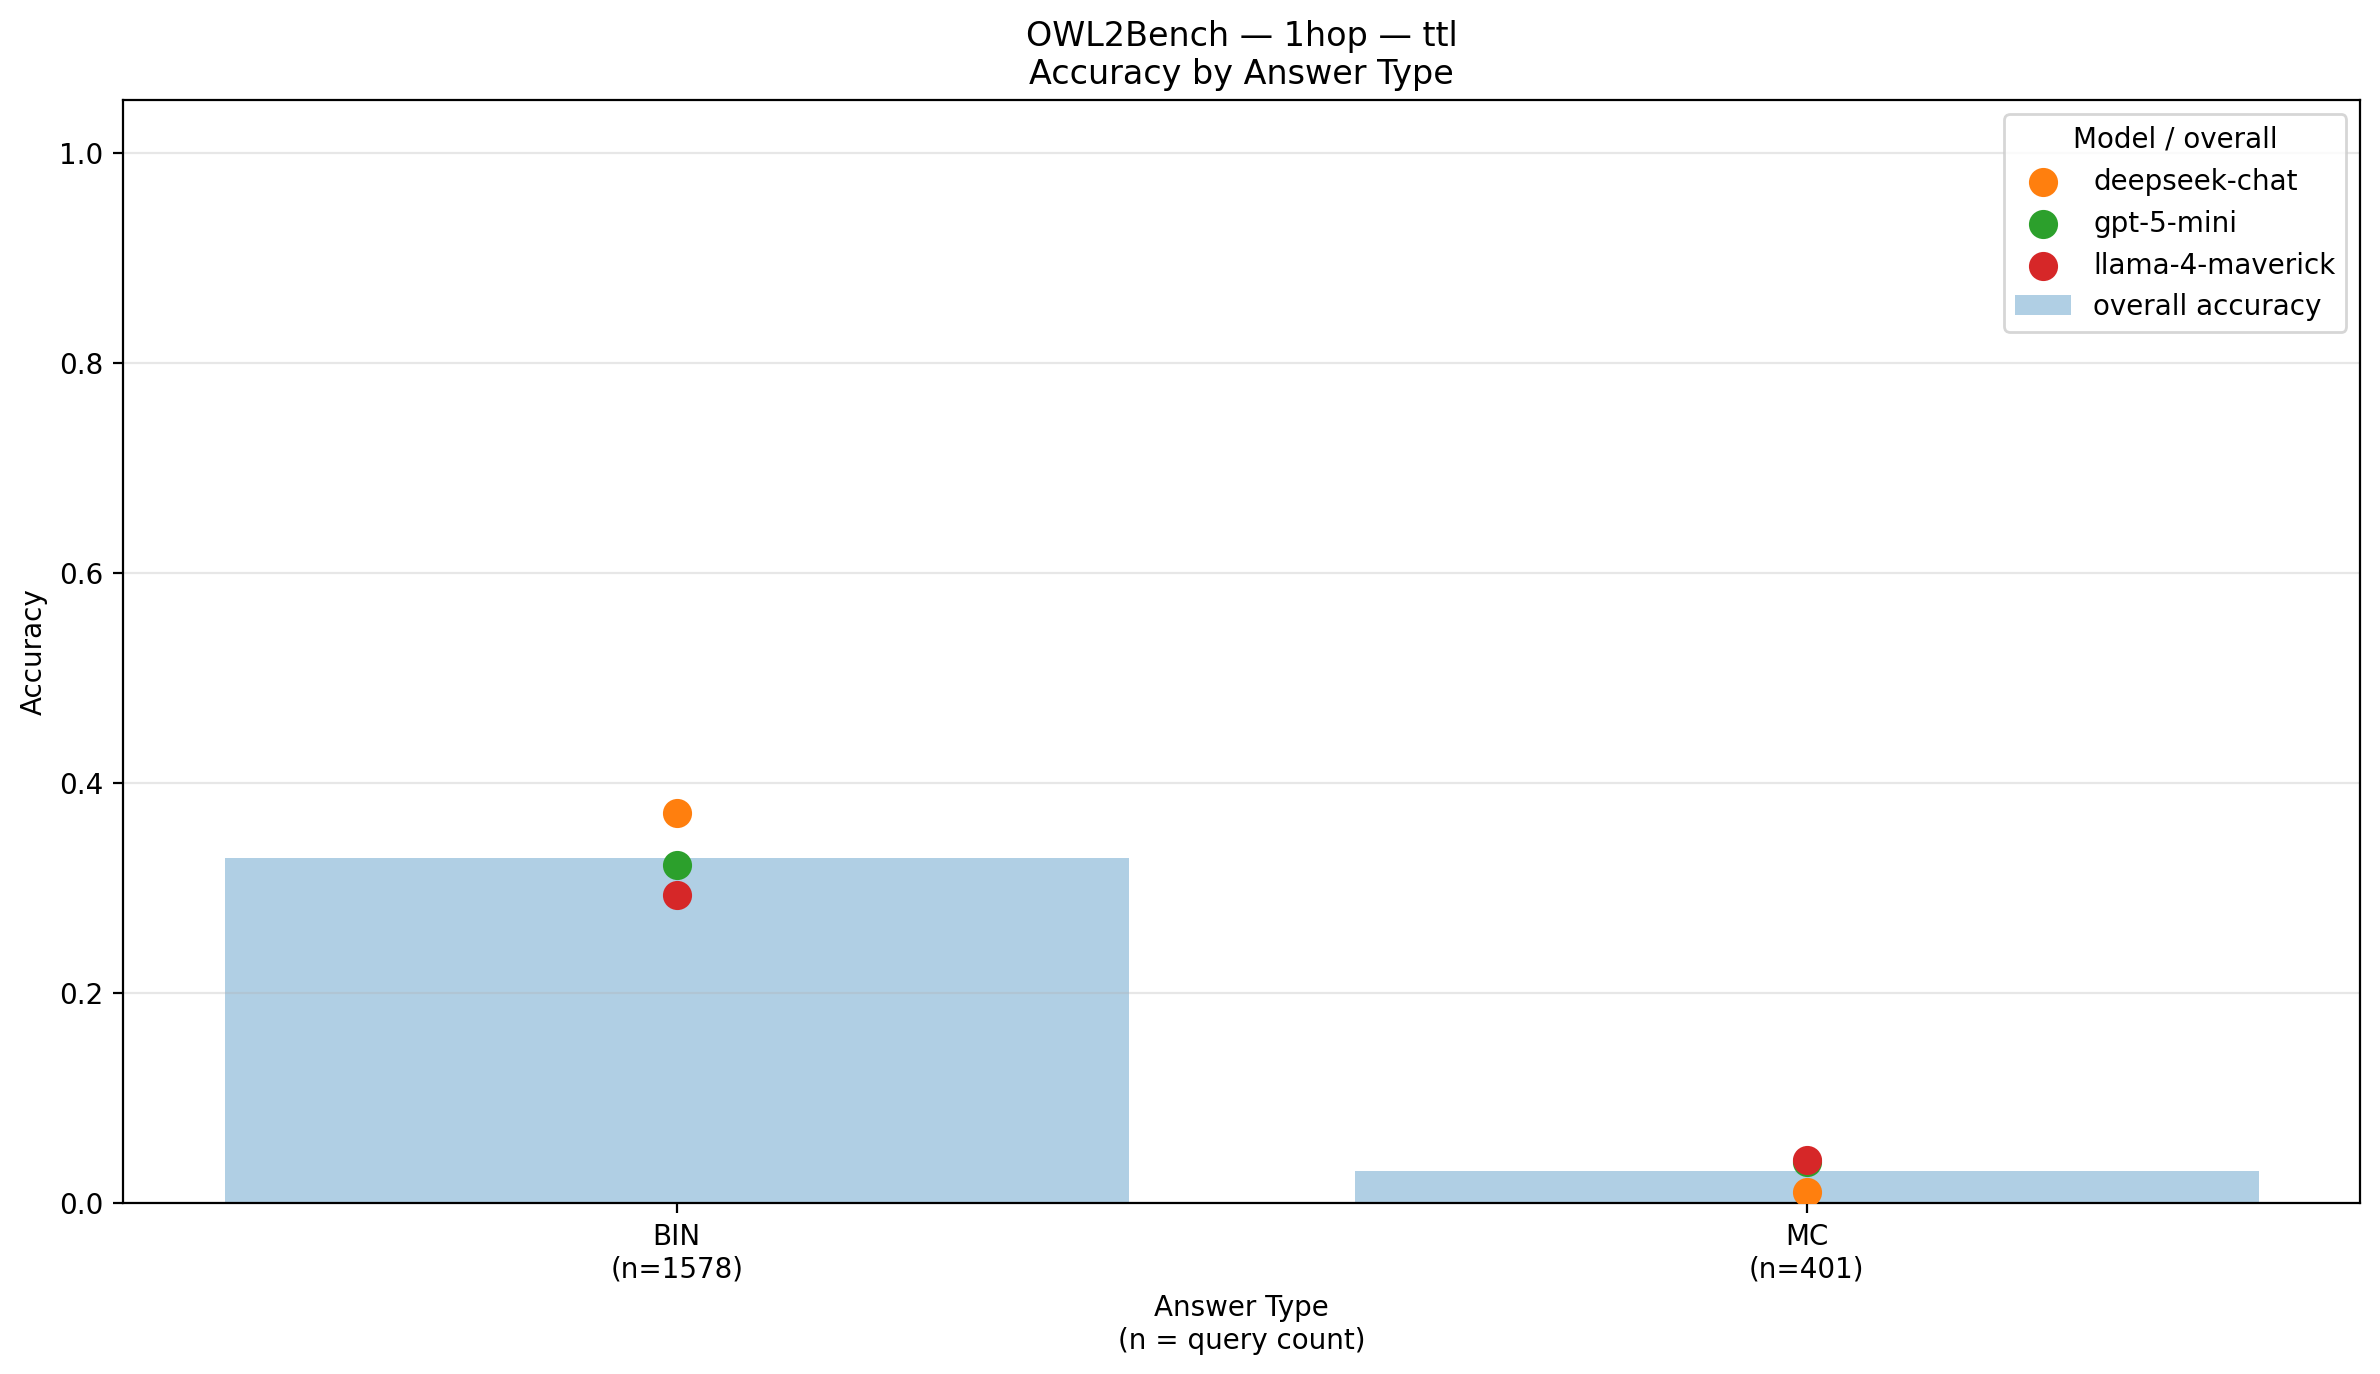

OWL2Bench_2hop_ab_max_tag_length_accuracy.png


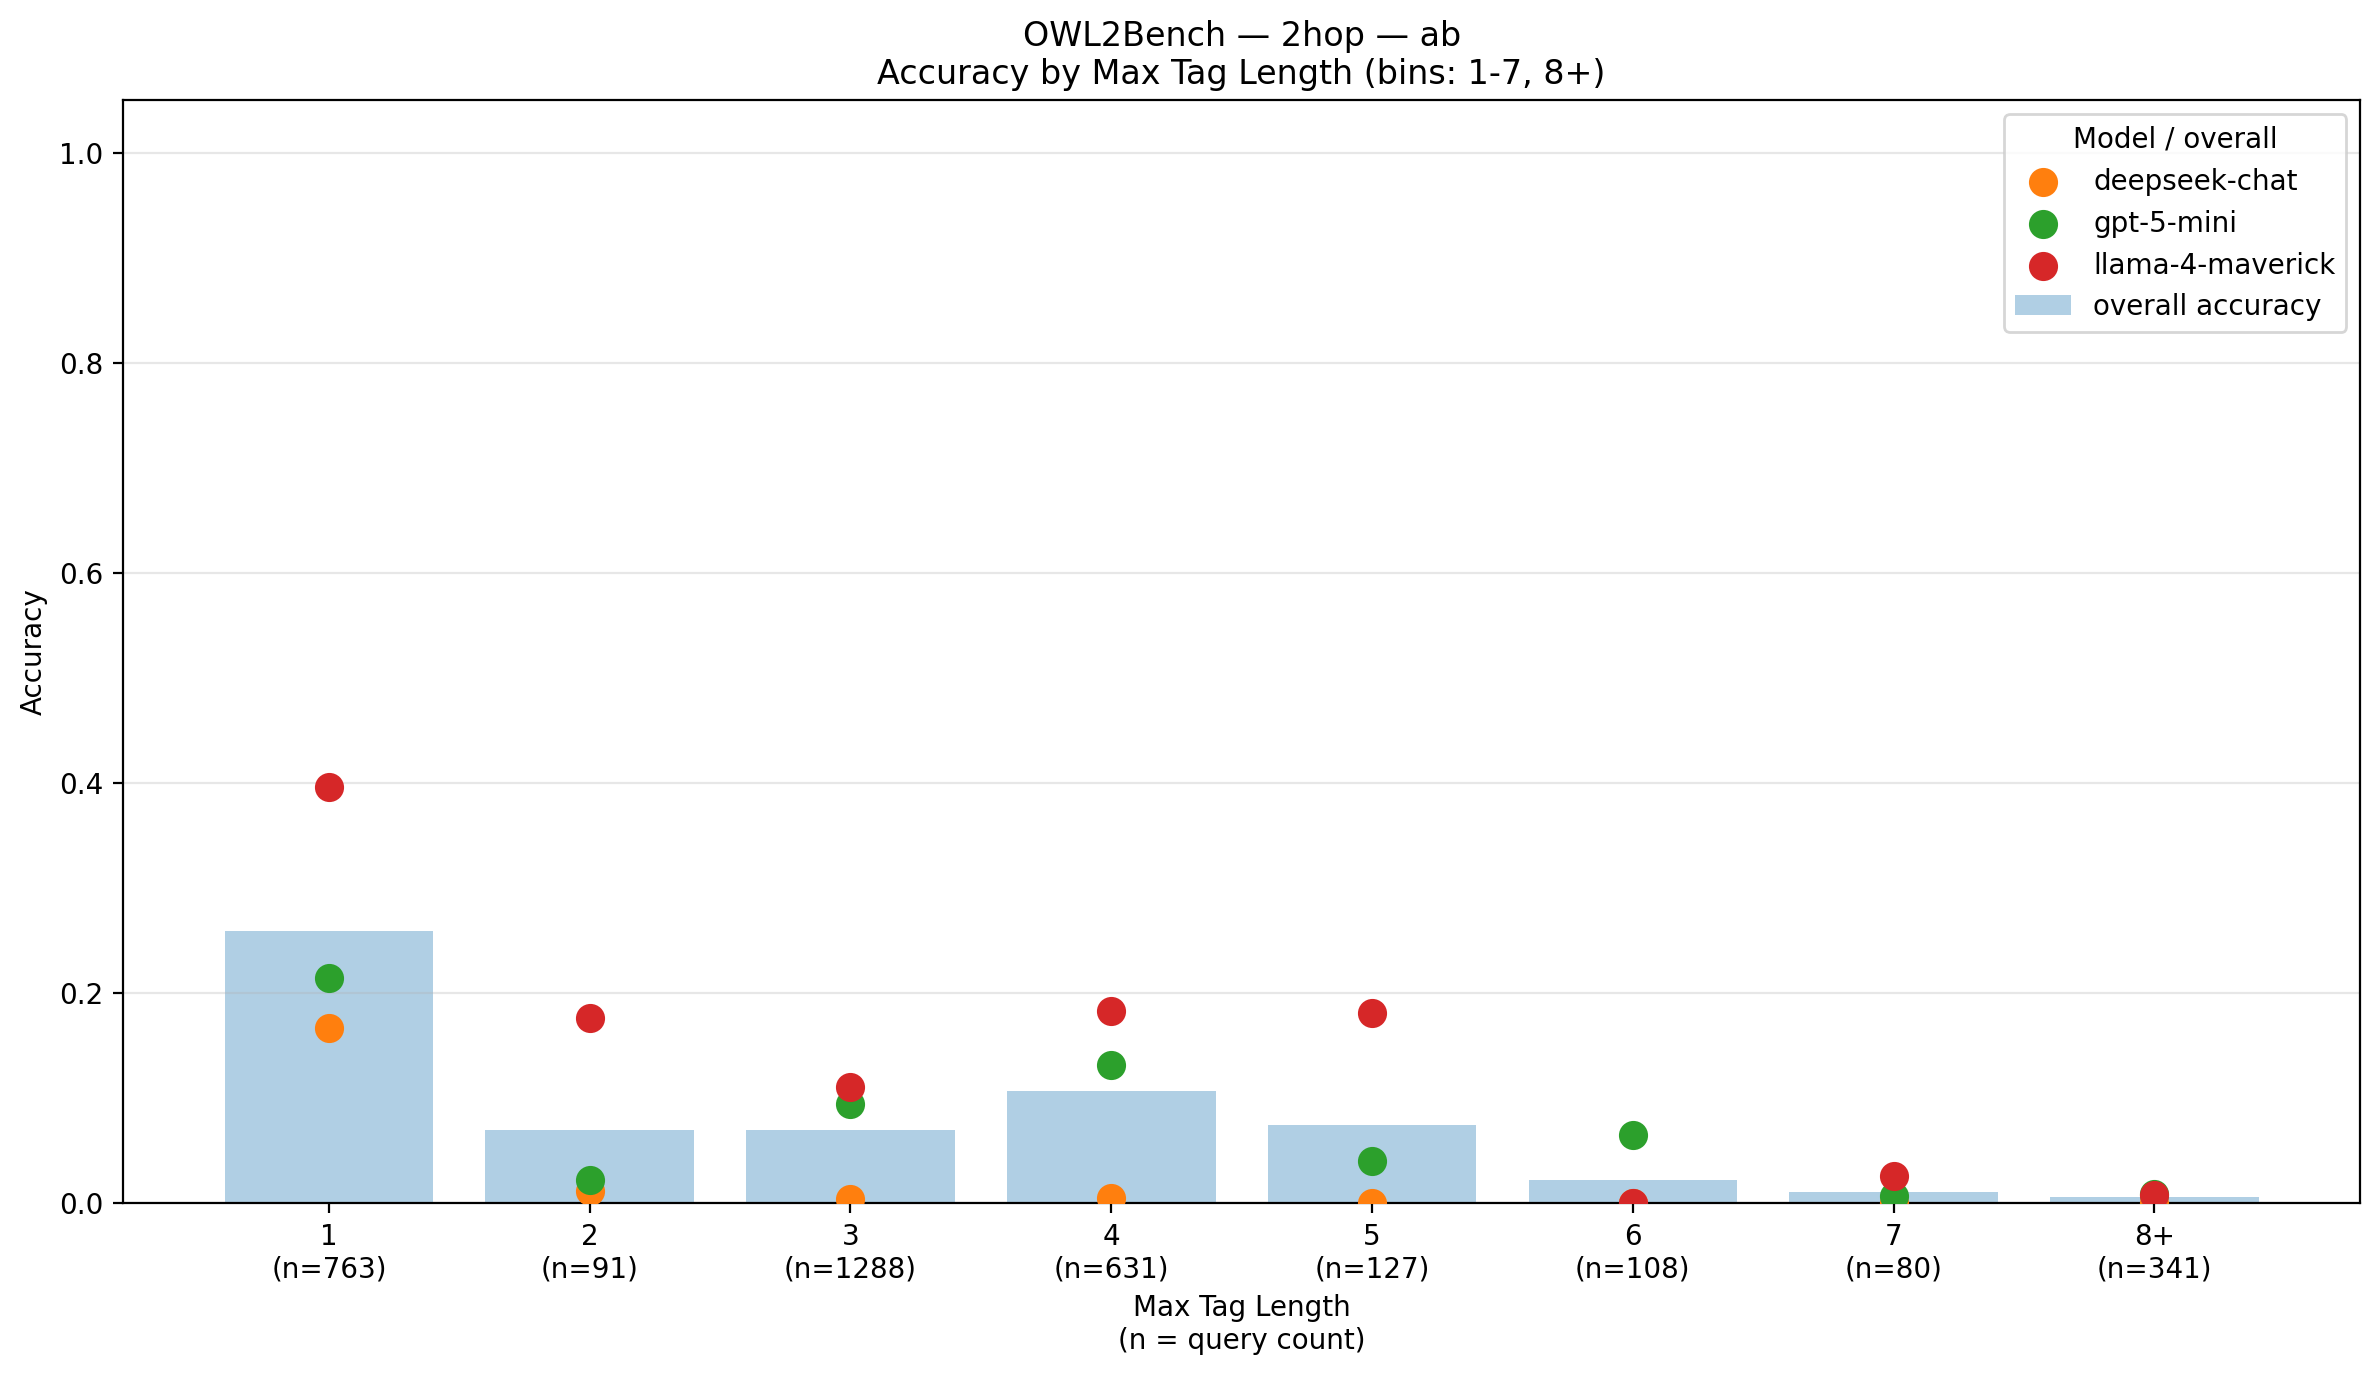

In [24]:
sample_specs = [
    ("OWL2Bench", "1hop", "nl", "abox_size"),
    ("OWL2Bench", "1hop", "ttl", "answer_type"),
    ("OWL2Bench", "2hop", "ab", "max_tag_length"),
]

for ontology_name, hop, setting, parameter_key in sample_specs:
    img_path = PLOTS_DIR / f"{ontology_name}_{hop}_{setting}_{parameter_key}_accuracy.png"
    print(img_path.name)
    if img_path.exists():
        display(Image(filename=str(img_path)))
    else:
        print("Missing:", img_path)